# QED - NN - Polar Code

## Initialization

In [1]:
import stim
import stim
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from wrappers.stim_wrapper import (create_circuit_polar_stim_normal, convert_i_to_meas_type, 
simulate_batch_and_save_result_polar_normal)

from wrappers.polar_wrapper import is_q1prep_accepted, get_logical_error_on_accepted_states, get_q1prep_accepted_states




In [2]:

def create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed):
    N = 2**(n)
    ancilla_qubits = 2**(n - 1)
    total_qubits = N + ancilla_qubits
    meas_type = convert_i_to_meas_type(i, n, lstate)
    print(meas_type, sim_type, "total qubits:", total_qubits, ", total ancilla:", ancilla_qubits)
    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    circuit = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, None, None, None, meas_type, total_qubits, x_ind)
    return circuit



In [3]:
def set_global_seeds(seed=12345):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## Functions

In [4]:
import torch
import torch.nn.functional as F

tensor = torch.tensor([[1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0]])

# Padding tuple format in PyTorch goes backwards: (pad_left, pad_right, pad_top, pad_bottom)
result = F.pad(tensor, (4, 0), value=0)

print(result)

tensor([[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0]])


['z', 'z', 'z', 'x', 'z'] m1 total qubits: 48 , total ancilla: 16


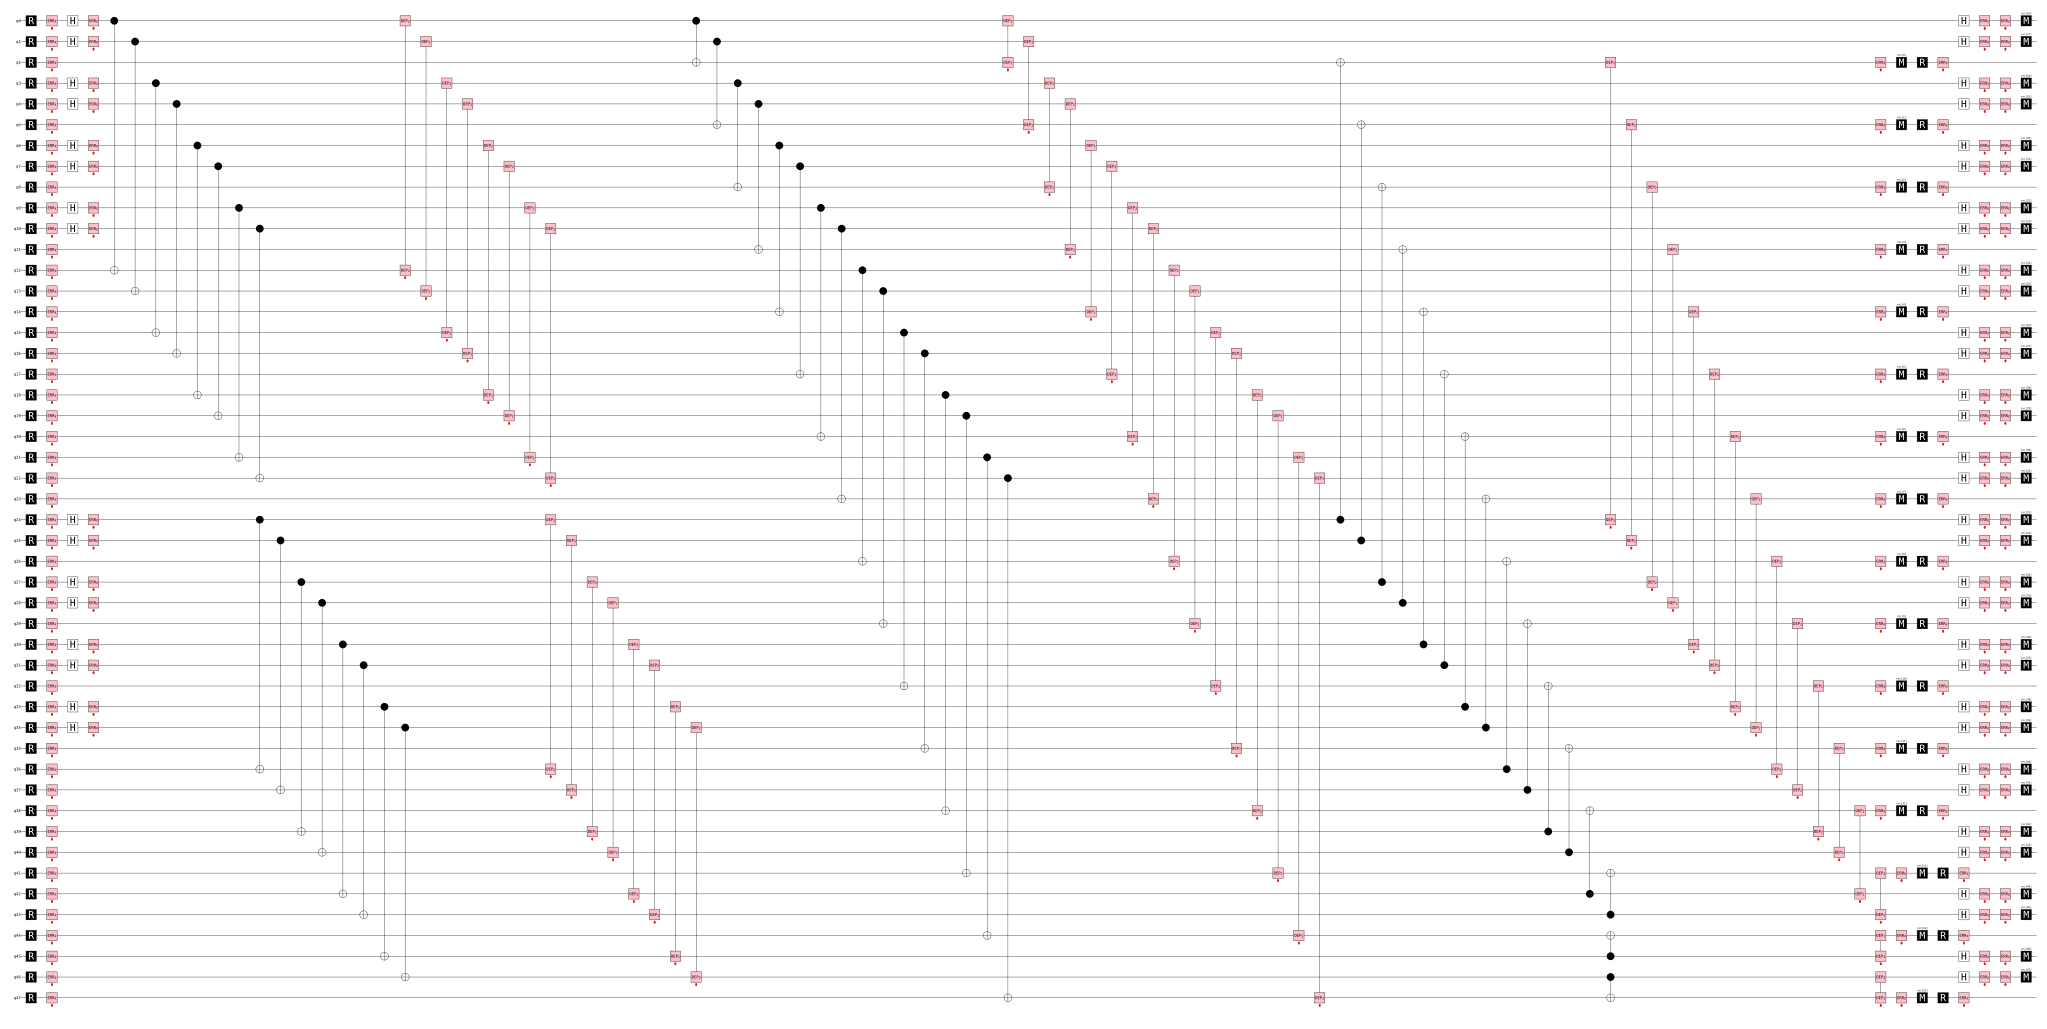

In [6]:
n = 5
i = 25
lstate = "x"

# n = 4
# i = 6
# lstate = "z"
p_error = 0
shots = int(1e4)
seed = 1000

sim_type = "m1"
polar_n4 = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)
polar_n4.diagram("timeline-svg")

In [7]:
# n = 5
# i = 25
# lstate = "x"
p_error = 0
shots = int(1e4)
seed = 10000

sim_type = "m1"
polar_n4 = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)

sampler_noisy = polar_n4.compile_sampler(seed=1000)
raw_measurements = sampler_noisy.sample(shots=shots)

raw_measurements__ = raw_measurements.astype(int)
tens = torch.tensor(raw_measurements__)
raw_measurements_int = F.pad(tens, (2**(n-1), 0), value=0).numpy()

meas_type = convert_i_to_meas_type(i, n, lstate)
x_ind = 0
for idx, m_type in enumerate(meas_type):
    if m_type == "x":
        x_ind = idx
        break
total_meas_ancilla = 2**(n-1) * (n - x_ind )

syndromes = raw_measurements_int[:, :total_meas_ancilla]

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

print(n, lstate, total_meas_ancilla, (2**(n-1))) 
print("sy:", syndromes[0]) 
print("r0:", raw_measurements__[0]) 
print("r1:", raw_measurements_int[0])

print(is_q1prep_accepted(n, lstate, zpos_list, syndromes[0]))

total_success = 0
for s in syndromes:
    # print(n, zpos, s)
    total_success = total_success + is_q1prep_accepted(n, lstate, zpos_list, s)    

print("total:", total_success)

# accepted_mask = np.array([is_q1prep_accepted(n, i-1, s) for s in syndromes], dtype=int)
# accepted_mask




['z', 'z', 'z', 'x', 'z'] m1 total qubits: 48 , total ancilla: 16
5 x 32 16
sy: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1]
r0: [1 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 0 1 0 0 0 0 1 0 1 0
 0 0 1 1 0 1 0 1 1 0 0]
r1: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0
 1 0 1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 1 1 0 1 0 1 1 0 0]
1
total: 10000


In [8]:
counts = {}
N     = 2**n
print(n, N) 

# n = 5
# i = 25
zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i -1

for res in raw_measurements:
    bit_string = ""
    for j in res:
        if j:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if sim_type in ["m1", "m2", "m3"]:
        bit_string = bit_string + "0"*(2**(n - 1))

    if bit_string in counts:
        counts[bit_string] = counts[bit_string] + 1
    else:
        counts[bit_string] = 1  

# total_success = 0
# for line, meas_counts in counts.items():
#         # print(line)
#         # remove spaces at beginning and end of line
#         mstr = line.strip()

#         # init the measurement results array -- of length len(mstr)
#         meas = np.zeros((len(mstr),), dtype=int) 

#         # convert from string to np array
#         for idx in range(0, len(mstr)):
#             meas[idx] = ord(mstr[i]) - ord('0')	
#             if meas[idx] != 0 and meas[idx] != 1:
#                 raise TypeError("Illegal measurement result: must be 0 or 1")

#         total_success = total_success + is_q1prep_accepted(n, lstate, zpos_list, meas[:N-1:-1])
#         # print(meas[:N-1:-1])
#         # print(meas)
        

# print("total:", total_success)

# success_states, data_qubit_states = get_q1prep_accepted_states(n, lstate.upper(), counts, zpos_list)

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = \
            get_logical_error_on_accepted_states(
                n, lstate.upper(), counts, zpos_list
            )

print(count_accept, count_accept/len(raw_measurements), count_logerror, count_undecided, 1-ler, detect_normal, decoding_normal)

5 32
10000 1.0 0 0 0.0 0 5.844384509837255


### Data Generation

In [9]:
def generate_filtered_qed_dataset(n, i, lstate, sim_type, p_error, is_accepted_func, num_shots=100000, seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

    circuit = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, 0, 0)

    meas_type = convert_i_to_meas_type(i, n, lstate)
    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break
    
    # 1. Sample Noisy Data from Hardware / Stim
    sampler_noisy = circuit.compile_sampler(seed=seed)
    raw_measurements = sampler_noisy.sample(shots=num_shots).astype(int)


    if sim_type == "normal":
        pass
    elif sim_type == "m1":
        # print("masuk sini gak sih", len(raw_measurements[0]))
        tens = torch.tensor(raw_measurements)
        raw_measurements = F.pad(tens, (2**(n-1), 0), value=0).numpy()

    total_meas_ancilla = 2**(n-1) * (n-x_ind)
    syndromes = raw_measurements[:, :total_meas_ancilla]

    data_measurements = raw_measurements[:, total_meas_ancilla:]

    # print("raw:", raw_measurements[0], len(raw_measurements[0]))
    # print("data:", data_measurements[0], len(data_measurements[0]))
    print(x_ind, 2**(n-1), total_meas_ancilla, sim_type, n)
    print("synd:", syndromes[0], len(syndromes[0]))
    
    # 3. Ground Truth: Target error status of Information Qubit Q3 (Index 3)
    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i-1
    info_idx = i-1
    y_target = data_measurements[:, info_idx].reshape(-1, 1).astype(np.float32)
    
    # 4. Filter using your custom Classical Acceptance Function
    # Checks each syndrome vector against your classical error detection rules

    
    
    accepted_mask = np.array([is_accepted_func(n, lstate, zpos_list, s) for s in syndromes], dtype=bool)
    # print(sum(accepted_mask))
    
    rejected_mask = ~accepted_mask
    
    # Extract ONLY rejected shots for training the NN
    X_rejected = syndromes[rejected_mask].astype(np.float32)
    Y_rejected = y_target[rejected_mask]
    
    # Performance Baseline Metrics
    total_accepted = accepted_mask.sum()
    total_rejected = rejected_mask.sum()
    
    print("="*55)
    print("        DATASET GENERATION WITH CLASSICAL FILTERING       ")
    print("="*55)
    print(f"Total Shots Simulated     : {num_shots}")
    print(f"Classically Accepted      : {total_accepted} ({100 * total_accepted / num_shots:.2f}% Yield)")
    print(f"Classically Rejected      : {total_rejected} ({100 * total_rejected / num_shots:.2f}% Sent to NN)")
    print("="*55)
    
    return (
        torch.tensor(X_rejected), 
        torch.tensor(Y_rejected), 
        torch.tensor(syndromes, dtype=torch.float32), 
        torch.tensor(y_target),
        torch.tensor(raw_measurements, dtype=torch.float32)
    )

In [10]:
n = 5
i = 25
lstate = "x"

# n = 4
# i = 6
lstate = "z"

p_error = 0
shots = int(1e4)
seed = 10101
sim_type = "m1"

result = generate_filtered_qed_dataset(n, i, lstate, sim_type, p_error, is_q1prep_accepted, num_shots=shots, seed=seed)
# result 

['x', 'x', 'x', 'z', 'z'] m1 total qubits: 48 , total ancilla: 16
0 16 80 m1 5
synd: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0
 0 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0
 0 1 0 1 0 1] 80
        DATASET GENERATION WITH CLASSICAL FILTERING       
Total Shots Simulated     : 10000
Classically Accepted      : 10000 (100.00% Yield)
Classically Rejected      : 0 (0.00% Sent to NN)


## Neural Network Model

In [11]:
def evaluate_cascaded_qed(model, n, i, X_test_all, Y_test_all, Data_test_all, is_accepted_func, error_prob = 0.5):
    model.eval()
    with torch.no_grad():
        num_shots = len(X_test_all)

        zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
        zpos_list[n] = i-1
        zpos = zpos_list[n]
        
        # Step 1: Classical Acceptance
        classical_mask = np.array([is_accepted_func(n, lstate, zpos_list, s.numpy()) for s in X_test_all], dtype=bool)
        
        # Step 2: NN Rescues from Rejected Pool
        rejected_mask = ~classical_mask
        X_rejected = X_test_all[rejected_mask]
        
        nn_rescued_mask = torch.zeros(num_shots, dtype=torch.bool)
        if len(X_rejected) > 0:
            logits = model(X_rejected)
            probs = torch.sigmoid(logits)
            
            # Keep states where NN predicts error probability < 0.5
            rescued_indices = (probs < 0.75).squeeze().cpu().numpy()
            rejected_indices = np.where(rejected_mask)[0]
            rescued_global_indices = rejected_indices[rescued_indices]
            nn_rescued_mask[rescued_global_indices] = True

        # Combine both masks
        total_accepted_mask = torch.tensor(classical_mask) | nn_rescued_mask
        
        # --- NEW: EXTRACT THE ACCEPTED STATES ---
        accepted_syndromes = X_test_all[total_accepted_mask]
        accepted_data_bits = Data_test_all[total_accepted_mask]
        
        # Calculate Metrics
        final_yield = total_accepted_mask.float().mean().item()
        final_fidelity = 1.0 - Y_test_all[total_accepted_mask].mean().item() if total_accepted_mask.sum() > 0 else 1.0

        print(f"Final Yield: {final_yield*100:.2f}% | Final Fidelity: {final_fidelity*100:.2f}%")
        
        # Return the matrices for your SC Decoder
        return accepted_syndromes, accepted_data_bits

In [12]:
def verify_with_our_function(final_data):
    # Handle empty dataset right away
    total_len = len(final_data)
    if total_len == 0:
        return 0, 0, 0.0, 0.0, 0.0

    counts = {}
    for res in final_data:
        bit_string = ""
        for j in res:
            if j:
                bit_string = "1" + bit_string
            else:
                bit_string = "0" + bit_string

        counts[bit_string] = counts.get(bit_string, 0) + 1

    (
        count_accept,
        count_logerror,
        count_undecided,
        ler,
        detect_normal,
        decoding_normal,
    ) = get_logical_error_on_accepted_states(
        n, lstate.upper(), counts, zpos_list
    )

    # Safe division calculations
    prep_rate = count_accept / total_len if total_len > 0 else 0.0

    ler_clean = (
        (count_logerror - (count_undecided / 2)) / count_accept
        if count_accept > 0
        else 1
    )

    one_minus_ler = 1 - ler if ler is not None else 1

    return count_accept, total_len, prep_rate, ler_clean, one_minus_ler

#### Sequential

In [374]:
# class SmartQEDFilter(nn.Module):
#     def __init__(self):
#         super(SmartQEDFilter, self).__init__()
#         self.net = nn.Sequential(
#             nn.Linear(12, 128),
#             nn.BatchNorm1d(128),
#             nn.ReLU(),
#             nn.Dropout(0.2),
            
#             nn.Linear(128, 64),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Dropout(0.2),
            
#             nn.Linear(64, 32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
            
#             nn.Linear(32, 1)
#         )

#     def forward(self, x):
#         return self.net(x)

In [375]:
# def training_model(n, i, lstate, sim_type, is_accepted_func, train_shots, train_seed, test_shots, test_seed, batch_size, adam_lr, epochs):
#     print("="*55)
#     print("        PREPARING DATASETS       ")
#     print("="*55)
#     # Generate Training Data (we only use X_train_rejected and Y_train_rejected)
#     X_train_rej, Y_train_rej, _, _, _ = generate_filtered_qed_dataset(
#         n, i, lstate, sim_type, p_error, is_accepted_func, num_shots=train_shots, seed=train_seed
#     )
    
#     # Generate Testing Data (we keep the ALL sets for evaluation)
#     _, _, X_test_all, Y_test_all, data_test_all = generate_filtered_qed_dataset(
#         n, i, lstate, sim_type, p_error, is_accepted_func, num_shots=test_shots, seed=test_seed
#     )

#     train_loader = DataLoader(TensorDataset(X_train_rej, Y_train_rej), batch_size=batch_size, shuffle=True)

#     model = SmartQEDFilter()
#     optimizer = optim.Adam(model.parameters(), lr=adam_lr)
    
#     # Handle severe class imbalance in the rejected set
#     num_positives = Y_train_rej.sum()
#     num_negatives = len(Y_train_rej) - num_positives
#     pos_weight = num_negatives / torch.clamp(num_positives, min=1.0)
#     criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#     print("\n" + "="*55)
#     print("        TRAINING NEURAL NETWORK       ")
#     print("="*55)
    
#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0
#         for batch_x, batch_y in train_loader:
#             optimizer.zero_grad()
#             logits = model(batch_x)
#             loss = criterion(logits, batch_y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
            
#         print(f"Epoch {epoch+1:02d}/{epochs:02d} | Loss: {total_loss/len(train_loader):.4f}")

#     return model, X_test_all, Y_test_all, data_test_all

    

In [376]:
# train_shots, train_seed = int(1e4), 12345
# test_shots, test_seed = int(1e3), 54321
# batch_size, adam_lr, epochs = 256, 0.0001, 10
# n = 4
# i = 7
# lstate = "z"
# p_error = 0.005


In [377]:
# sim_type = "normal"

# model_sequential_base, x_test_base, y_test_base, data_base = training_model(n, i, lstate, sim_type, is_q1prep_accepted, train_shots, train_seed, test_shots, test_seed, batch_size, adam_lr, epochs)

In [378]:
# sim_type = "m1"
# model_sequential_prop1, x_test_prop1, y_test_prop1, data_prop1 = training_model(n, i, lstate, sim_type, is_q1prep_accepted, train_shots, train_seed, test_shots, test_seed, batch_size, adam_lr, epochs)

In [379]:
# # Run the final evaluation
# # evaluate_cascaded_qed(model, X_test_all, Y_test_all, is_q1prep_accepted)
# final_syndromes_base, final_data_bits_base = evaluate_cascaded_qed(
#     model_sequential_base, n, i, x_test_base, y_test_base, data_base, is_q1prep_accepted
# )

In [380]:
# # Run the final evaluation
# # evaluate_cascaded_qed(model, X_test_all, Y_test_all, is_q1prep_accepted)
# final_syndromes_prop1, final_data_bits_prop1 = evaluate_cascaded_qed(
#     model_sequential_prop1, n, i, x_test_prop1, y_test_prop1, data_prop1, is_q1prep_accepted
# )

In [381]:
# verify_with_our_function(final_data_bits_base)
# verify_with_our_function(final_data_bits_prop1)
# verify_with_our_function(data_base)
# verify_with_our_function(data_prop1)
# pass

### Residual Block + NN

In [13]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout_rate=0.2):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))

class ScalablePolarQED(nn.Module):
    def __init__(self, n, x_ind, sim_type, include_data_bits=False):
        """
        Dynamically builds the QED network based on n, x_ind, and sim_type.
        """
        super(ScalablePolarQED, self).__init__()
        
        # 1. Base Dimensions
        self.n = n
        self.x_ind = x_ind
        self.N = 2 ** n                 
        self.aux_qubits = self.N // 2   
        
        # 2. Calculate Active Measurement Layers
        self.active_layers = n - x_ind
        
        # # If sim_type is "m1", we skip one more layer of Pauli measurements
        # if sim_type == "m1":
        #     self.active_layers -= 1
            
        # Safety check to ensure we don't end up with 0 or negative layers
        self.active_layers = max(1, self.active_layers)
            
        # 3. Calculate Exact Input Dimension (No 0-padding needed anymore!)
        self.syndrome_bits = self.active_layers * self.aux_qubits 
        self.total_bits = self.syndrome_bits + self.N
        
        self.input_dim = self.total_bits if include_data_bits else self.syndrome_bits
        
        # 4. Scale Network Capacity based on n (Polar Graph Complexity)
        self.hidden_dim = 128 * (2 ** (n - 3)) 
        self.num_blocks = n - 1 
        
        print("="*55)
        print(f"       DYNAMIC MODEL INITIALIZED (n={self.n}, N={self.N})       ")
        print("="*55)
        print(f"Base Layers      : {n} (Skipped {x_ind} due to x_ind)")
        print(f"Sim Type Adjust  : {'-1 Layer' if sim_type == 'm1' else 'None'} ({sim_type})")
        print(f"Active Layers    : {self.active_layers}")
        print(f"Input Dimension  : {self.input_dim} bits (No padding required)")
        print(f"Hidden Dimension : {self.hidden_dim} neurons per layer")
        print("="*55)

        # 5. Build Network Architecture
        self.input_layer = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            nn.BatchNorm1d(self.hidden_dim),
            nn.GELU()
        )
        
        self.res_blocks = nn.ModuleList([
            ResidualBlock(self.hidden_dim) for _ in range(self.num_blocks)
        ])
        
        self.output_layer = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim // 2),
            nn.BatchNorm1d(self.hidden_dim // 2),
            nn.GELU(),
            nn.Linear(self.hidden_dim // 2, 1) 
        )

    def forward(self, x):
        x = self.input_layer(x)
        for block in self.res_blocks:
            x = block(x)
        x = self.output_layer(x)
        return x

In [14]:
# model = ScalablePolarQED(n=5, x_ind=3, sim_type="m1", include_data_bits=False)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

def training_model(model, n, i, lstate, sim_type, p_error, is_accepted_func, train_shots, train_seed, test_shots, test_seed, batch_size, adam_lr, epochs, device="cpu"):
    """
    Universal training loop for Quantum Error Detection models.
    """
    print("="*55)
    print("        PREPARING DATASETS       ")
    print("="*55)

    print(n, i, lstate, sim_type, p_error)
    
    # Generate Training Data
    X_train_rej, Y_train_rej, _, _, _ = generate_filtered_qed_dataset(
        n, i, lstate, sim_type, p_error, is_accepted_func, num_shots=train_shots, seed=train_seed
    )
    
    # Generate Testing Data
    _, _, X_test_all, Y_test_all, data_test_all = generate_filtered_qed_dataset(
        n, i, lstate, sim_type, p_error, is_accepted_func, num_shots=test_shots, seed=test_seed
    )

    # Move data to the specified device (CPU or GPU)
    X_train_rej = X_train_rej.to(device)
    Y_train_rej = Y_train_rej.to(device)
    
    train_loader = DataLoader(TensorDataset(X_train_rej, Y_train_rej), batch_size=batch_size, shuffle=True)

    # Move the dynamically passed model to the device
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=adam_lr)
    
    # Handle severe class imbalance in the rejected set
    num_positives = Y_train_rej.sum()
    num_negatives = len(Y_train_rej) - num_positives
    pos_weight = num_negatives / torch.clamp(num_positives, min=1.0)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print("\n" + "="*55)
    print(f"   TRAINING NEURAL NETWORK (Device: {device.upper()})   ")
    print("="*55)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Loss: {total_loss/len(train_loader):.4f}")

    # Move test sets to device for evaluation later (optional, depending on your eval func)
    return model, X_test_all, Y_test_all, data_test_all

In [16]:
set_global_seeds()

In [18]:
# 1. Define your experiment parameters
n = 5  # Code length level (N=16)
i = 25  # Information qubit index or similar parameter
lstate = 'x'

# n = 4  # Code length level (N=16)
# i = 6  # Information qubit index or similar parameter
# lstate = 'z'

batch_size = 512
adam_lr = 0.001
epochs = 200
p_error = 0.005
meas_type = convert_i_to_meas_type(i, n, lstate)

train_shots=int(5e5) 
train_seed=101010 
test_shots=int(5e4) 
test_seed=202020

x_ind = 0
for idx, m_type in enumerate(meas_type):
    if m_type == "x":
        x_ind = idx
        break

print(x_ind)

3


In [19]:
# sim_type = 'normal'

# # Automatically use GPU if available, otherwise CPU
# device = "cuda" if torch.cuda.is_available() else "cpu"

# # Initialize the model with the new parameters
# my_model = ScalablePolarQED(
#     n=n, 
#     x_ind=x_ind, 
#     sim_type=sim_type, 
#     include_data_bits=False
# )

# # 3. Run the universal training function
# trained_model, X_test, Y_test, data_test = training_model(
#     model=my_model,              # <--- Inject the model here
#     n=n, 
#     i=i, 
#     lstate=lstate, 
#     sim_type=sim_type, 
#     p_error=p_error,
#     is_accepted_func=is_q1prep_accepted, 
#     train_shots=int(5e4), 
#     train_seed=1010, 
#     test_shots=int(5e3), 
#     test_seed=2020, 
#     batch_size=batch_size, 
#     adam_lr=adam_lr, 
#     epochs=epochs,
#     device=device                # <--- Pass the device here
# )

# # 4. Evaluate (Make sure your evaluate function also handles device mapping if using GPU)
# final_syndromes, final_data_bits = evaluate_cascaded_qed(
#     trained_model, n, i, X_test, Y_test, data_test, is_q1prep_accepted
# )

In [ ]:
sim_type = 'm1'

# Automatically use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize the model with the new parameters
my_model = ScalablePolarQED(
    n=n, 
    x_ind=x_ind, 
    sim_type=sim_type, 
    include_data_bits=False
)

# 3. Run the universal training function
trained_model_m1, X_test_m1, Y_test_m1, data_test_m1 = training_model(
    model=my_model,              # <--- Inject the model here
    n=n, 
    i=i, 
    lstate=lstate, 
    sim_type=sim_type, 
    p_error=p_error,
    is_accepted_func=is_q1prep_accepted, 
    train_shots=train_shots, 
    train_seed=train_seed, 
    test_shots=test_shots, 
    test_seed=test_seed, 
    batch_size=batch_size, 
    adam_lr=adam_lr, 
    epochs=epochs,
    device=device                # <--- Pass the device here
)

# 4. Evaluate (Make sure your evaluate function also handles device mapping if using GPU)
final_syndromes_m1, final_data_bits_m1 = evaluate_cascaded_qed(
    trained_model_m1, n, i, X_test_m1, Y_test_m1, data_test_m1, is_q1prep_accepted
)

       DYNAMIC MODEL INITIALIZED (n=5, N=32)       
Base Layers      : 5 (Skipped 3 due to x_ind)
Sim Type Adjust  : -1 Layer (m1)
Active Layers    : 2
Input Dimension  : 32 bits (No padding required)
Hidden Dimension : 512 neurons per layer
        PREPARING DATASETS       
5 25 x m1 0.005
['z', 'z', 'z', 'x', 'z'] m1 total qubits: 48 , total ancilla: 16
3 16 32 m1 5
synd: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 0 1 0 1] 32


In [ ]:
len(final_data_bits_m1[0]), N//2*(n-x_ind)

(40, 24)

In [ ]:
# verify_with_our_function(final_data_bits)
verify_with_our_function(final_data_bits_m1)
# verify_with_our_function(data_test)
# verify_with_our_function(data_test_m1)
# pass

(33424, 49241, 0.6787839402124246, 5.983724269985639e-05, 0.00209430349449502)

In [ ]:
# Generate Testing Data
_, _, X_test_all, Y_test_all, data_test_all = generate_filtered_qed_dataset(
    n, i, lstate, sim_type, p_error, is_q1prep_accepted, num_shots=int(1e6), seed=1239895
)


['z', 'x', 'z', 'x'] m1 total qubits: 24 , total ancilla: 8
1 8 24 m1 4
synd: [0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 1 0 1 1] 24
        DATASET GENERATION WITH CLASSICAL FILTERING       
Total Shots Simulated     : 1000000
Classically Accepted      : 668945 (66.89% Yield)
Classically Rejected      : 331055 (33.11% Sent to NN)


In [ ]:
p_error

0.005

In [ ]:
# # 4. Evaluate (Make sure your evaluate function also handles device mapping if using GPU)
# final_syndromes_m1, final_data_bits_m1 = evaluate_cascaded_qed(
#     trained_model_m1, n, i, X_test_all, Y_test_all, data_test_all, is_q1prep_accepted
# )

Final Yield: 76.97% | Final Fidelity: 50.02%


In [ ]:
# verify_with_our_function(final_data_bits_m1)
# verify_with_our_function(data_test_all)


# # Epoch 100

(148635, 1000000, 0.148635, 0.0005382312375954519, 0.00708446866485013)

In [ ]:
# final_data_bits_m1[0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1.])

In [ ]:
import torch

def direct_nn_prediction(model, X_all, data_all, device="cpu", error_prob = 0.5):
    """
    Evaluates the entire dataset using only the Neural Network.
    Bypasses classical filtering entirely.
    """
    print("="*55)
    print("        DIRECT NEURAL NETWORK INFERENCE       ")
    print("="*55)
    
    # 1. Set the model to evaluation mode (disables dropout/batchnorm updates)
    model.eval()
    
    # 2. Ensure data is on the correct device
    X_all = X_all.to(device)
    
    with torch.no_grad():
        # 3. Forward pass: get the raw logits for all shots
        logits = model(X_all)
        
        # 4. Convert logits to probabilities (0.0 to 1.0)
        probs = torch.sigmoid(logits)
        
        # 5. Threshold the probabilities
        # Assuming < 0.5 means the network predicts the information qubit is SAFE (0)
        nn_accepted_mask = (probs < error_prob).squeeze().cpu()
        
    # 6. Apply the mask to extract only the states the NN deemed safe
    accepted_syndromes = X_all.cpu()[nn_accepted_mask]
    accepted_data_bits = data_all.cpu()[nn_accepted_mask]
    
    # Calculate metrics
    total_shots = len(X_all)
    accepted_shots = len(accepted_syndromes)
    yield_percentage = (accepted_shots / total_shots) * 100
    
    print(f"Total Shots Evaluated : {total_shots}")
    print(f"States Accepted by NN : {accepted_shots}")
    print(f"Direct NN Yield       : {yield_percentage:.2f}%")
    print("="*55)
    
    # Return the clean, accepted matrices for the SC Decoder
    return accepted_syndromes, accepted_data_bits, nn_accepted_mask

In [ ]:
# Assuming you have already run generate_filtered_qed_dataset to get these variables:
# X_test_all: The syndrome bits (e.g., shape [30000, 16])
# data_test_all: The data bits for SC decoding (e.g., shape [30000, 16])

device = "cuda" if torch.cuda.is_available() else "cpu"

final_syndromes, final_data_bits, acceptance_mask = direct_nn_prediction(
    model=trained_model_m1,
    X_all=X_test_all,
    data_all=data_test_all,
    device=device,
    error_prob=0.85
)



# final_data_bits is now ready to be handed to your SC Decoder!



        DIRECT NEURAL NETWORK INFERENCE       
Total Shots Evaluated : 1000000
States Accepted by NN : 989353
Direct NN Yield       : 98.94%


In [ ]:
# verify_with_our_function(final_data_bits)


# # i = 6
# # (91663,
# #  607112,
# #  0.15098202638063488,
# #  0.0006382073464756773,
# #  0.007156649902359757)

# # i = 7
# # Epoch 100
# # (666712,
# #  958155,
# #  0.6958289629548455,
# #  0.0001867373018634733,
# #  0.005285640576440764)

# # Epoch 250
# # (668614,
# #  950975,
# #  0.7030826257262284,
# #  0.00018695390763579585,
# #  0.005279578351634839)

In [ ]:
verify_with_our_function(data_test_all)
# i = 6
# x
# (148635, 1000000, 0.148635, 0.0005382312375954519, 0.00708446866485013)
# z
# (668945, 1000000, 0.668945, 5.2321192325228533e-05, 0.0021915105128224033)

# i = 7
# Epoch 100 X
# (668614, 1000000, 0.668614, 0.00018695390763579585, 0.005279578351634839)
# Z
# (580226, 1000000, 0.580226, 3.791626021584693e-05, 0.001442541354575666)

# n = 5



# 667811 0.667811 1000000 3466 6697 0.005190091208440717

(668945, 1000000, 0.668945, 5.2321192325228533e-05, 0.0021915105128224033)

#### m1 n4x i7, 0.005, 1M, epoch 250

In [87]:
# import torch

# # --- SAVING ---
# # Save only the learned parameters
# torch.save(trained_model_m1.state_dict(), "NN_Model/residual_block_m1_n4_x_i7_0.005_ep250_1M.pth")

# # --- LOADING ---
# # 1. Instantiate the model class first
# model = ScalablePolarQED(n, x_ind, sim_type)

# # 2. Load the parameter dictionary into the model
# model.load_state_dict(torch.load("NN_Model/residual_block_m1_n4_x_i7_0.005_ep250_1M.pth"))

# # 3. Always set to evaluation mode if running inference
# model.eval()

#### m1 n4z i7, 0.005, 1M, epoch 250

In [171]:
# import torch

# # --- SAVING ---
# # Save only the learned parameters
# torch.save(trained_model_m1.state_dict(), "NN_Model/residual_block_m1_n4_z_i7_0.005_ep200_1M.pth")

# # --- LOADING ---
# # 1. Instantiate the model class first
# model = ScalablePolarQED(n, x_ind, sim_type)

# # 2. Load the parameter dictionary into the model
# model.load_state_dict(torch.load("NN_Model/residual_block_m1_n4_z_i7_0.005_ep200_1M.pth"))

# # 3. Always set to evaluation mode if running inference
# model.eval()

#### m1 n4x i6, 0.005, 1M, epoch 200

In [ ]:
# torch.save(trained_model_m1.state_dict(), "NN_Model/residual_block_m1_n4_x_i6_0.005_ep200_1M.pth")

#### m1 n4z i6, 0.005, 1M, epoch 200

In [ ]:
# torch.save(trained_model_m1.state_dict(), "NN_Model/residual_block_m1_n4_z_i6_0.005_ep200_1M.pth")

<!-- #### Testing different Error Probs -->

In [ ]:
# Assuming you have already run generate_filtered_qed_dataset to get these variables:
# X_test_all: The syndrome bits (e.g., shape [30000, 16])
# data_test_all: The data bits for SC decoding (e.g., shape [30000, 16])



def simulate_direct_nn_prediction_by_error_prob(model, X_all, data_all, error_prob):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    final_syndromes, final_data_bits, acceptance_mask = direct_nn_prediction(
        model=trained_model_m1,
        X_all=X_test_all,
        data_all=data_test_all,
        device=device,
        error_prob=error_prob
    )

    count_accept, total_data, prep_rate, ler_clean, ler_all = verify_with_our_function(final_data_bits)

    print("Error Prob:", error_prob, ", PR:", prep_rate, ", LER:", ler_clean, ", count:", count_accept, ", total data:", total_data, "ler_all:", ler_all)

    return count_accept, total_data, prep_rate, ler_clean, ler_all

# final_data_bits is now ready to be handed to your SC Decoder!

In [49]:
np.linspace(0.1, 0.45, 8)

array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45])

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

model = trained_model_m1
X_all = X_test_all
data_all = data_test_all
device = device

# ---------------------------------------------------------
# 1. PREPARE FILE PATH & INITIALIZE CSV
# ---------------------------------------------------------
output_file = "NN_Model/simulation_results_{lstate}_n{n}_i{i}.csv"

# Ensure target directory exists
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Define column structure
columns = [
    "error_prob",
    "count_accept",
    "total_data",
    "prep_rate",
    "ler_clean",
    "ler_all",
]

# Initialize an empty CSV file with headers (overwrites old runs)
pd.DataFrame(columns=columns).to_csv(output_file, index=False)

# ---------------------------------------------------------
# 2. RUN SIMULATION & APPEND EACH RESULT IMMEDIATELY
# ---------------------------------------------------------
model.eval()
error_probs = np.linspace(0.5, 1.0, 11)
# error_probs = np.linspace(0.1, 0.45, 8)

for p in error_probs:
    p_val = float(p)

    count_accept, total_data, prep_rate, ler_clean, ler_all = (
        simulate_direct_nn_prediction_by_error_prob(
            model, X_all, data_all, p_val
        )
    )

    result_row = {
        "error_prob": p_val,
        "count_accept": count_accept,
        "total_data": total_data,
        "prep_rate": prep_rate,
        "ler_clean": ler_clean,
        "ler_all": ler_all,
    }

    # Convert single row to DataFrame and append directly to file
    pd.DataFrame([result_row]).to_csv(
        output_file, mode="a", header=False, index=False
    )

    print(f"Checkpoint saved for p = {p_val:.2f}")

print(f"\nAll results successfully written to {output_file}")

        DIRECT NEURAL NETWORK INFERENCE       


Total Shots Evaluated : 1000000
States Accepted by NN : 10354
Direct NN Yield       : 1.04%
Error Prob: 0.1 , PR: 0.0 , LER: 0.0 , count: 0 , total data: 10354 ler_all: 1
Checkpoint saved for p = 0.10
        DIRECT NEURAL NETWORK INFERENCE       
Total Shots Evaluated : 1000000
States Accepted by NN : 11461
Direct NN Yield       : 1.15%
Error Prob: 0.15 , PR: 0.0 , LER: 0.0 , count: 0 , total data: 11461 ler_all: 1
Checkpoint saved for p = 0.15
        DIRECT NEURAL NETWORK INFERENCE       
Total Shots Evaluated : 1000000
States Accepted by NN : 12767
Direct NN Yield       : 1.28%
Error Prob: 0.2 , PR: 0.0 , LER: 0.0 , count: 0 , total data: 12767 ler_all: 1
Checkpoint saved for p = 0.20
        DIRECT NEURAL NETWORK INFERENCE       
Total Shots Evaluated : 1000000
States Accepted by NN : 14857
Direct NN Yield       : 1.49%
Error Prob: 0.25 , PR: 0.0 , LER: 0.0 , count: 0 , total data: 14857 ler_all: 1
Checkpoint saved for p = 0.25
        DIRECT NEURAL NETWORK INFERENCE       
Total 

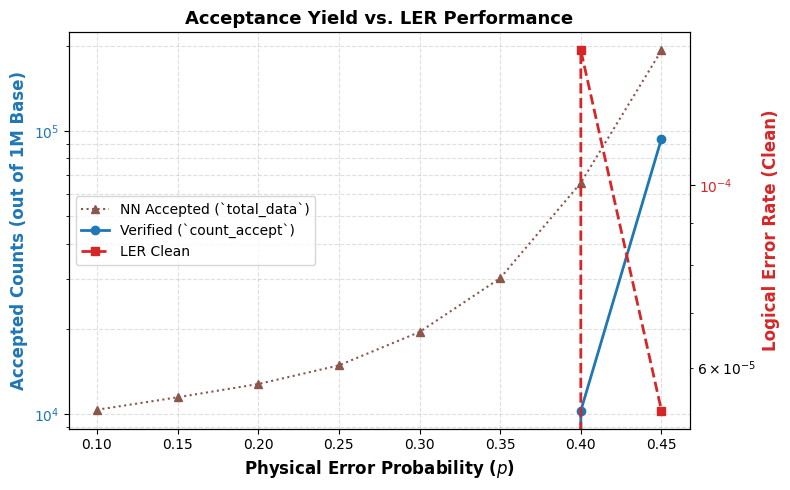

In [ ]:
df = pd.read_csv(f"NN_Model/simulation_results_{lstate}_n{n}_i{i}.csv")
fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Left Axis: Counts (Log Scale) ---
color1 = "#1f77b4"
ax1.set_xlabel(
    "Physical Error Probability ($p$)", fontsize=12, fontweight="bold"
)
ax1.set_ylabel(
    "Accepted Counts (out of 1M Base)", color=color1, fontsize=12, fontweight="bold"
)
ax1.set_yscale("log")

line1 = ax1.plot(
    df["error_prob"],
    df["total_data"],
    color="#8c564b",
    marker="^",
    linestyle=":",
    linewidth=1.5,
    label="NN Accepted (`total_data`)",
)
line2 = ax1.plot(
    df["error_prob"],
    df["count_accept"],
    color=color1,
    marker="o",
    linewidth=2,
    label="Verified (`count_accept`)",
)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, which="both", linestyle="--", alpha=0.4)

# --- Right Axis: LER Clean (Log Scale) ---
color2 = "#d62728"
ax2 = ax1.twinx()
ax2.set_ylabel(
    "Logical Error Rate (Clean)", color=color2, fontsize=12, fontweight="bold"
)
ax2.set_yscale("log")

line3 = ax2.plot(
    df["error_prob"],
    df["ler_clean"],
    color=color2,
    marker="s",
    linewidth=2,
    linestyle="--",
    label="LER Clean",
)
ax2.tick_params(axis="y", labelcolor=color2)

# Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center left")

plt.title("Acceptance Yield vs. LER Performance", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("twin_axis_simulation.png", dpi=300)
plt.show()

# Z
# (580226, 1000000, 0.580226, 3.791626021584693e-05, 0.001442541354575666)

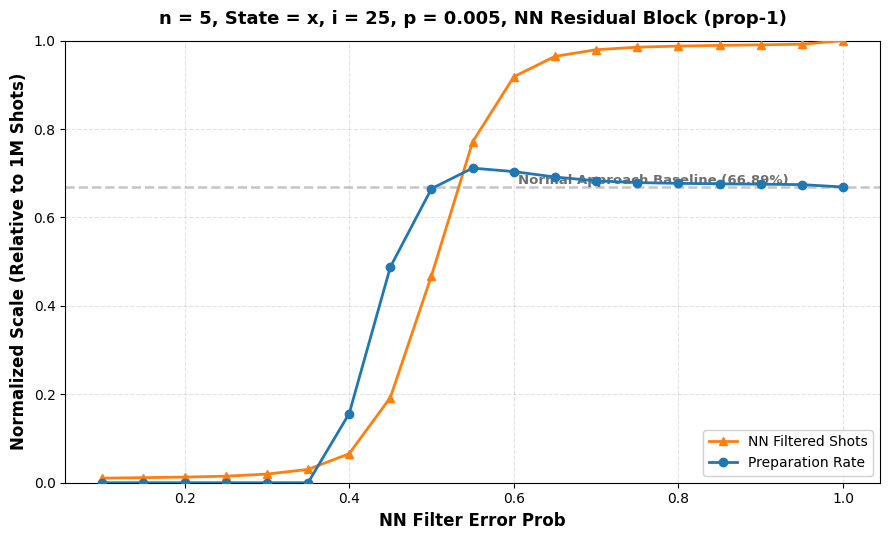

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load simulation results
# df = pd.read_csv("simulation_results.csv")
df = pd.read_csv("NN_Model/simulation_results_z_n4_i6.csv")

N_base = 1_000_000
# baseline_count = 580226
# baseline_count = 668614
# baseline_count = 148635
baseline_count = 668945



# Normalize values so 1M shots = scale 1.0
df["scale_nn"] = df["total_data"] / N_base
df["scale_verified"] = df["count_accept"] / df["total_data"]
baseline_scale = baseline_count / N_base

fig, ax = plt.subplots(figsize=(9, 5.5))

# ---------------------------------------------------------
# A. BACKGROUND BASELINE (Faded, no legend, with text)
# ---------------------------------------------------------
ax.axhline(
    y=baseline_scale,
    color="gray",
    linestyle="--",
    linewidth=1.8,
    alpha=0.45,  # Faded background look
    zorder=1,
)
ax.text(
    x=0.605,
    y=baseline_scale * 1,
    s=f"Normal Approach Baseline ({baseline_scale:.2%})",
    color="#4a4a4a",
    fontsize=9.5,
    fontweight="bold",
    alpha=0.8,
    va="bottom",
)

# ---------------------------------------------------------
# B. TOTAL SHOTS LINE (1,000,000 = Scale 1.0)
# ---------------------------------------------------------
# ax.axhline(
#     y=1.0,
#     color="#333333",
#     linestyle="-",
#     linewidth=1.5,
#     label="Total Shots Base (1,000,000)",
#     zorder=2,
# )

# ---------------------------------------------------------
# C. SIMULATION DATA LINES
# ---------------------------------------------------------
# NN Filtered compared to 1M Base
ax.plot(
    df["error_prob"],
    df["scale_nn"],
    marker="^",
    color="#ff7f0e",
    linewidth=2,
    label="NN Filtered Shots",
    zorder=3,
)

# Verified Accepted
ax.plot(
    df["error_prob"],
    df["scale_verified"],
    marker="o",
    color="#1f77b4",
    linewidth=2,
    label="Preparation Rate",
    zorder=4,
)

# ---------------------------------------------------------
# D. FORMATTING
# ---------------------------------------------------------
# ax.set_yscale("log")
ax.set_ylim(bottom=df["scale_verified"].min() * 0.7, top=1)  # Cap scale at 1.0

ax.set_xlabel("NN Filter Error Prob", fontsize=12, fontweight="bold")
ax.set_ylabel(
    "Normalized Scale (Relative to 1M Shots)", fontsize=12, fontweight="bold"
)
ax.set_title(
    "n = 5, State = x, i = 25, p = 0.005, NN Residual Block (prop-1)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(fontsize=10, loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.savefig("normalized_1m_scale_plot_x_n5_25.png", dpi=300)
plt.show()

#### Breaking Down

In [198]:
n = 4
i = 7
lstate = "x"
sim_type = "m1"
p_error = 0
train_shots=int(1e4) 
train_seed=101
test_shots=int(1e3) 
test_seed=202 

X_train_rej, Y_train_rej, _, _, _ = generate_filtered_qed_dataset(
        n, i, lstate, sim_type, p_error, is_q1prep_accepted, num_shots=train_shots, seed=train_seed
    )

['z', 'x', 'z', 'x'] m1
10000
        DATASET GENERATION WITH CLASSICAL FILTERING       
Total Shots Simulated     : 10000
Classically Accepted      : 10000 (100.00% Yield)
Classically Rejected      : 0 (0.00% Sent to NN)
